In [1]:
import pandas as pd
import shap
shap.initjs()

In [2]:
import sys
sys.path.append("..")
from helper_functions.prep_data_function import prepare_train_test
X_train, X_test, y_train, y_test = prepare_train_test("../data/cab_rides_features.csv")
X_train

,cab_type,name,source,destination,time_of_day,demand_density,distance,rides_in_hour_at_source,bad_weather_score,is_raining,is_weekend,ride_hour,uber_lyft_price_ratio
0,Lyft,Lux Black XL,Boston University,Theatre District,late_night,low,3.03,9,0.311602,False,False,3,NaN
1,Uber,Black,South Station,Theatre District,late_night,low,1.30,11,0.319336,False,False,3,NaN
2,Lyft,Lyft,Northeastern University,Beacon Hill,late_night,low,2.43,4,0.321602,False,False,3,NaN
3,Uber,UberXL,Theatre District,Fenway,late_night,low,2.71,13,0.318420,False,False,3,3.351081
4,Uber,UberX,Theatre District,Fenway,late_night,low,2.71,13,0.318420,False,False,3,3.351081
...,...,...,...,...,...,...,...,...,...,...,...,...,...
510380,Lyft,Lux,South Station,West End,evening,low,2.00,123,0.360612,False,True,17,0.912941
510379,Lyft,Lyft XL,South Station,West End,evening,low,2.00,123,0.360612,False,True,17,0.912941
510376,Lyft,Lux Black,South Station,West End,evening,low,2.00,123,0.360612,False,True,17,0.912941
510377,Lyft,Lyft,South Station,West End,evening,low,2.00,123,0.360612,False,True,17,0.912941


In [3]:
# Shared and UberPool are the pooled tiers, the model's biggest source of error in notebook 01 came from these rides, so this flags them explicitly instead of leaving the model to infer it from the name category alone
pooled_tiers = ["Shared", "UberPool"]
X_train["is_pooled"] = X_train["name"].isin(pooled_tiers)
X_test["is_pooled"] = X_test["name"].isin(pooled_tiers)
X_train["is_pooled"].value_counts()

is_pooled
False    425444
True      84938
Name: count, dtype: int64

In [4]:
val_cut = int(len(X_train) * 0.8)
X_tr, X_val = X_train.iloc[:val_cut], X_train.iloc[val_cut:]
y_tr, y_val = y_train.iloc[:val_cut], y_train.iloc[val_cut:]
X_tr.shape, X_val.shape

((408305, 14), (102077, 14))

In [5]:
import xgboost as xgb

best_params = {"max_depth": 6, "learning_rate": 0.1}

model = xgb.XGBRegressor(
    **best_params,
    n_estimators=1000,
    enable_categorical=True,
    tree_method="hist",
    random_state=42,
    early_stopping_rounds=20,
    eval_metric="rmse",
)
model.fit(X_tr,y_tr,eval_set=[(X_val,y_val)],verbose=False)
model.best_iteration

349

In [6]:
y_pred = model.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_true=y_test,y_pred=y_pred)

0.5597500427767925

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = mean_squared_error(y_true=y_test,y_pred=y_pred)**0.5
mae = mean_absolute_error(y_true=y_test,y_pred=y_pred)
rmse, mae

(0.19983335079359635, 0.11856030713576637)

In [8]:
y_train_pred = model.predict(X_train)
r2_score(y_true=y_train,y_pred=y_train_pred)

0.6143072260144574

In [9]:
import numpy as np
abs_err = np.abs(y_test.values - y_pred)
pd.Series(abs_err,index=X_test.index).groupby(X_test["is_pooled"]).mean()

is_pooled
False    0.099206
True     0.214676
dtype: float64

In [10]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

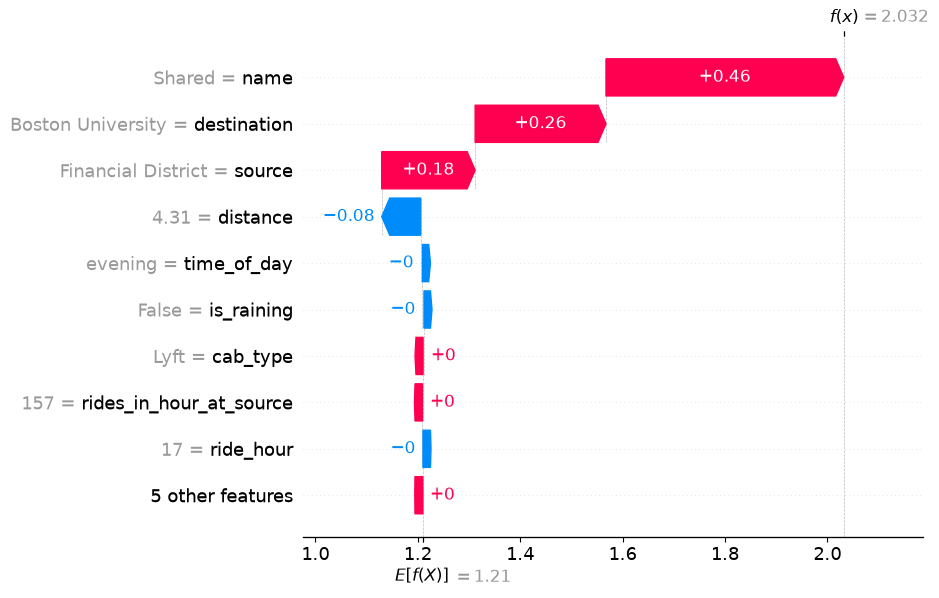

In [11]:
shap.plots.waterfall(shap_values[0])

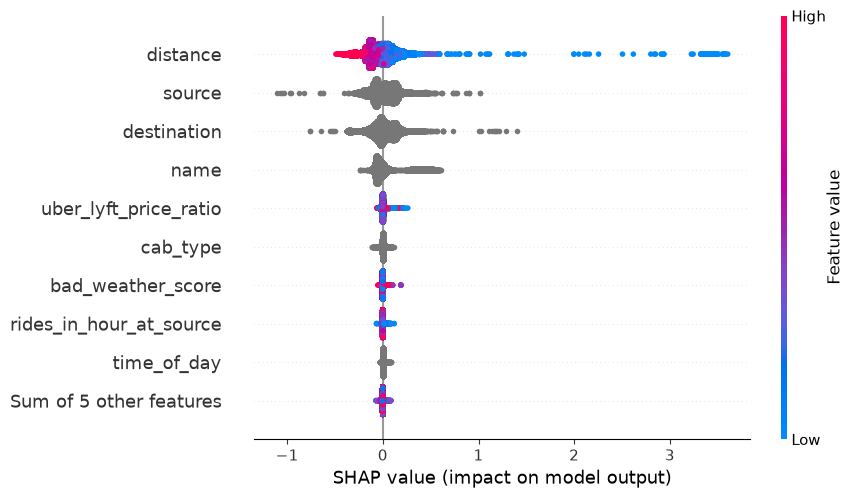

In [12]:
shap.plots.beeswarm(shap_values)